In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
from rasterio.features import geometry_mask
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
import rasterio
import rioxarray


uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})
# eg_upwind_masked=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_0.001.npy',)

In [3]:
# Load receiver sensitivity data from numpy file
rec = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_lai_months.npy')

# Load donor overlap data from numpy file
don = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_overlap.npy')

In [4]:
def get_asymmetric_mean(a, b):
    """
    Calculate asymmetric mean between two arrays
    
    Parameters:
        a: First input array
        b: Second input array
        
    Returns:
        Asymmetric mean calculated as (|a| - |b|) / (|a| + |b| + epsilon)
        Returns values in range [-1, 1] where positive values indicate |a| > |b|
    """
    return (np.abs(a) - np.abs(b)) / (np.abs(a) + np.abs(b) + 1e-10)

In [5]:
def sea_mask(da):
    """
    Create a land/sea mask based on natural Earth land dataset
    
    Parameters:
        da: xarray DataArray with latitude and longitude coordinates
        
    Returns:
        Boolean mask where True represents land areas, False represents ocean areas
    """
    # Load natural Earth land dataset using geopandas
    land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    # Optionally exclude Antarctica from the land dataset
    land = land[land['continent'] != 'Antarctica']
    
    # Create a transform object for coordinate transformation
    # based on the spatial extent and resolution of input DataArray
    transform = rasterio.transform.from_origin(
        da.longitude.min(), da.latitude.max(),
        (da.longitude.max() - da.longitude.min()) / len(da.longitude),
        (da.latitude.max() - da.latitude.min()) / len(da.latitude))
    
    # Create a boolean mask where True represents land areas
    # and False represents ocean areas
    mask = geometry_mask(
        land.geometry,  # Use land geometries to create the mask
        out_shape=(len(da.latitude), len(da.longitude)),  # Output shape matches input DataArray
        transform=transform,  # Coordinate transformation
        invert=True  # True=land areas, False=ocean areas
    )
    
    return mask

In [6]:
# Calculate mean receiver sensitivity across time dimension (axis=1), ignoring NaN values
rec_mean = np.nanmean(rec, axis=1)

# Calculate mean donor overlap across time dimension and select first component [:,0]
send_mean = np.nanmean(don, axis=1)[:, 0]

In [7]:
metric=get_asymmetric_mean(send_mean,rec_mean)

In [8]:
lonlim = (-82, -32)
latlim = (-60, 15)

In [9]:
# Load latitude and longitude coordinate arrays from numpy files
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")

# Create DataFrame with receiver sensitivity values and coordinates, then pivot to 2D grid
df_rec = pd.DataFrame({'rec': rec_mean, 'lat': lats, 'lon': lons}).pivot_table(
    index='lat', columns='lon', values='rec')
# Convert to xarray DataArray with proper dimensions and coordinates
da_rec = xr.DataArray(df_rec, dims=('lat', 'lon'), 
                     coords={'lat': df_rec.index, 'lon': df_rec.columns})

# Create DataFrame with donor overlap values and coordinates, then pivot to 2D grid
df_send = pd.DataFrame({'send': send_mean, 'lat': lats, 'lon': lons}).pivot_table(
    index='lat', columns='lon', values='send')
# Convert to xarray DataArray with proper dimensions and coordinates
da_send = xr.DataArray(df_send, dims=('lat', 'lon'), 
                      coords={'lat': df_send.index, 'lon': df_send.columns})

In [10]:
# Create DataFrame with metric values and corresponding coordinates, then pivot to 2D grid format
df_metric = pd.DataFrame({'value': metric, 'lat': lats, 'lon': lons}).pivot_table(
    index='lat', columns='lon', values='value')
# Convert pivoted DataFrame to xarray DataArray with proper dimensions and coordinate labels
da_metric = xr.DataArray(df_metric, dims=('lat', 'lon'), 
                        coords={'lat': df_metric.index, 'lon': df_metric.columns})

In [11]:
# Load global geography regions shapefile for additional geographic context
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)

# Load Amazon shapefile and read into GeoDataFrame
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)

# Dissolve all polygons into a single multi-polygon feature
# (Alternative commented line shows filtering for specific region before dissolving)
amazon_vector = amazon_vector.dissolve()
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Select the first (and only) feature from the dissolved GeoDataFrame
amazon_border = amazon_vector.loc[[0]]

In [12]:
# Load zonal wind component (u) data from NetCDF file
u0 = xr.open_dataarray('era5_850hpa_u0_average_wind_1d00_monthly.nc')

# Load meridional wind component (v) data from NetCDF file
v0 = xr.open_dataarray('era5_850hpa_v0_average_wind_1d00_monthly.nc')

In [13]:
# u0_land = np.where(sea_mask(u0), u0.values, np.nan)
# v0_land = np.where(sea_mask(v0), v0.values, np.nan)
# scale=10
# pu0_land= u0_land[0,::scale,::scale]
# pv0_land =v0_land[0,::scale,::scale]

In [14]:
# Set scaling factor for data resolution reduction
scale = 10

# Extract and downsample 850 hPa zonal wind component (every 10th data point)
pu0 = u0.sel(pressure_level=850)[::scale, ::scale]

# Extract and downsample 850 hPa meridional wind component (every 10th data point)
pv0 = v0.sel(pressure_level=850)[::scale, ::scale]

/tmp/ipykernel_2199647/240373339.py:47: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),
/tmp/ipykernel_2199647/240373339.py:72: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),


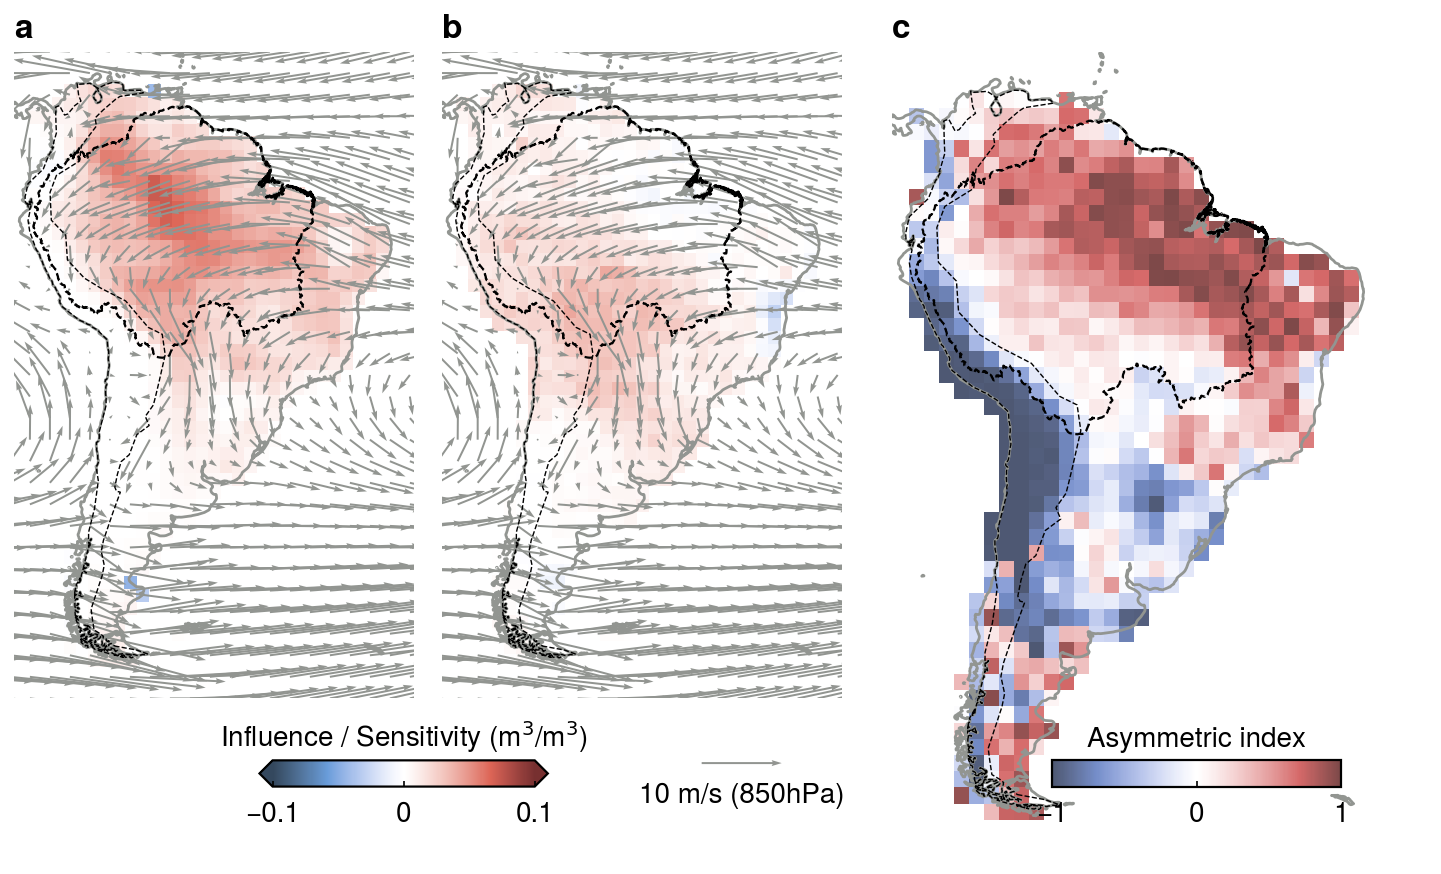

In [16]:
# Define map projection
proj = ccrs.PlateCarree()

# Define subplot arrangement (2x3 grid with specific layout)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2, 3],
    [0, 0, 3]
]

# Create figure with specified parameters
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection and layout parameters
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1, 1.5], height_ratios=[4, 1])
# Format axes with longitude and latitude limits
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

################################################
# First subplot: Donor sensitivity
ax = axs[0]
# Plot donor sensitivity values as colormesh
im = ax.pcolormesh(
    da_send.lon,
    da_send.lat,
    da_send.values,
    cmap='negpos',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=-0.1, vmax=0.1,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Create colorbar for sensitivity values
cax = fig.add_axes([0.18, 0.1, 0.2, 0.03], title='Influence / Sensitivity (m${^3}$/m${^3}$)', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='both',
    ticks=[-0.1, 0, 0.1],
)

# Plot wind vectors as quiver plot
qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(), 
               vmin=0, vmax=15, color='grey',
               scale=50,  # Adjust arrow size (smaller value = larger arrows)
               width=0.005)  # Arrow width

################################################
# Second subplot: Receiver sensitivity
ax = axs[1]
# Plot receiver sensitivity values as colormesh
im = ax.pcolormesh(
    da_rec.lon,
    da_rec.lat,
    da_rec.values,
    cmap='negpos',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=-0.1, vmax=0.1,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Plot wind vectors as quiver plot
qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(), 
               vmin=0, vmax=15, color='grey',
               scale=50,  # Adjust arrow size (smaller value = larger arrows)
               width=0.005)  # Arrow width

# Create quiver key for wind scale
handles = [ax.quiverkey(qv, 0.75, -0.1, 10, label='10 m/s (850hPa)', labelpos='S')]

################################################
# Third subplot: Asymmetric index
ax = axs[2]
# Plot asymmetric index values as colormesh with transparency
im = ax.pcolormesh(
    da_metric.lon,
    da_metric.lat,
    da_metric.values,
    cmap='div',
    discrete=False,
    transform=ccrs.PlateCarree(), alpha=0.9,
    vmin=-1, vmax=1,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Create colorbar for asymmetric index
cax = fig.add_axes([0.73, 0.1, 0.2, 0.03], title='Asymmetric index', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='neither',
    ticks=[-1, 0, 1],
)